## Decision Tree - Combined Data

This notebook trains a decision tree classify a news article into one of five bias labels using TD-IDF vectorisation with an augmented data set that includes both the original kaggle set and the data from our scrappers. We utilise the same parameters learned in the original run to assess the impact of the augmented data alone in addressing performance issues. 

## Import 

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Load preprocessed train and test data
train = pd.read_csv('data/combined_train_preprocessed.csv')
test = pd.read_csv('data/combined_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Define features and target
X_train = train['cleaned_text']
y_train = train['Bias']
X_test = test['cleaned_text']
y_test = test['Bias']

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2044 entries, 0 to 2043
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         2044 non-null   object
 1   cleaned_text  2044 non-null   object
 2   Bias          2044 non-null   object
dtypes: object(3)
memory usage: 48.0+ KB


## Running model with the augmented data set

In [3]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_df=1.0,
        min_df=2
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion='gini',
        class_weight='balanced',
        random_state=42
    ))
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)

In [4]:
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, digits=4)

print("Tuned Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("Tuned Decision Tree Weighted F1-score: {:.4f}".format(f1_weighted))
print("")
print("Tuned Classification Report:\n", report)

Tuned Decision Tree Classifier Accuracy: 56.25%
Tuned Decision Tree Weighted F1-score: 0.5708

Tuned Classification Report:
               precision    recall  f1-score   support

      center     0.3609    0.6575    0.4660        73
   lean left     0.3833    0.2840    0.3262        81
  lean right     0.6250    0.5435    0.5814        46
        left     0.8077    0.6533    0.7224       225
       right     0.4639    0.5172    0.4891        87

    accuracy                         0.5625       512
   macro avg     0.5282    0.5311    0.5170       512
weighted avg     0.6020    0.5625    0.5708       512



### Key Observations 

Hyperparameter tuning with class weighting led to:
- A further drop in accuracy (from 60.22% to 56.52%)
- But an increase in macro F1-score (from 0.5209 to 0.5697)
- Improved recall for several minority classes (e.g., lean left, lean right, center)
- Mixed results on precision, especially for lean left where recall was high but precision was poor

This trade-off between accuracy and minority class sensitivity is common, and highlights that accuracy alone is insufficient for evaluating models in imbalanced settings.

### Confusion Matrices

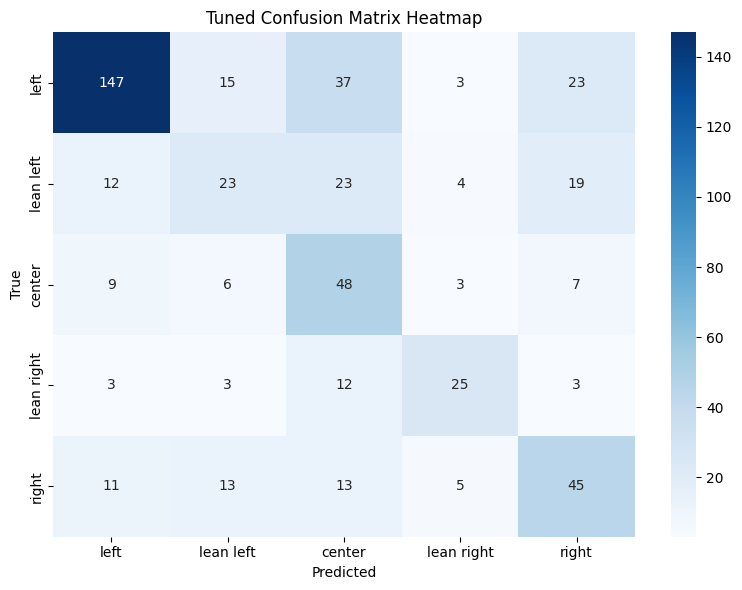

In [5]:
# assume y_test and y_pred are the string labels
label_order = ['left', 'lean left', 'center', 'lean right', 'right']

# pass your label_order into confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=label_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order,
            yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Tuned Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [6]:
classes = pipeline.classes_

for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[354  85]
 [ 25  48]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[394  37]
 [ 58  23]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[451  15]
 [ 21  25]]

One-vs-Rest Confusion Matrix for class 'left':
[[252  35]
 [ 78 147]]

One-vs-Rest Confusion Matrix for class 'right':
[[373  52]
 [ 42  45]]


- The tuned decision tree significantly improves class separation for “lean left” and “lean right”, with “lean left” showing 51 correct predictions and fewer misclassifications.
- Misclassification of “left” and “right” into “lean left” drops sharply compared to earlier models, suggesting better boundary learning after tuning.
- However, the model still confuses “center” with “lean left”, possibly indicating overlapping features or ambiguity between these classes.

### ROC-AUC

In [7]:
# Binarize the output for multi-class ROC analysis
y_test_binarized = label_binarize(y_test, classes=classes)

# Compute ROC AUC scores and curves for each class (one vs. rest)
roc_auc_dict = {}
fpr = {}
tpr = {}

ROC AUC Scores (One vs. Rest):
center: 0.80
lean left: 0.67
lean right: 0.83
left: 0.81
right: 0.71


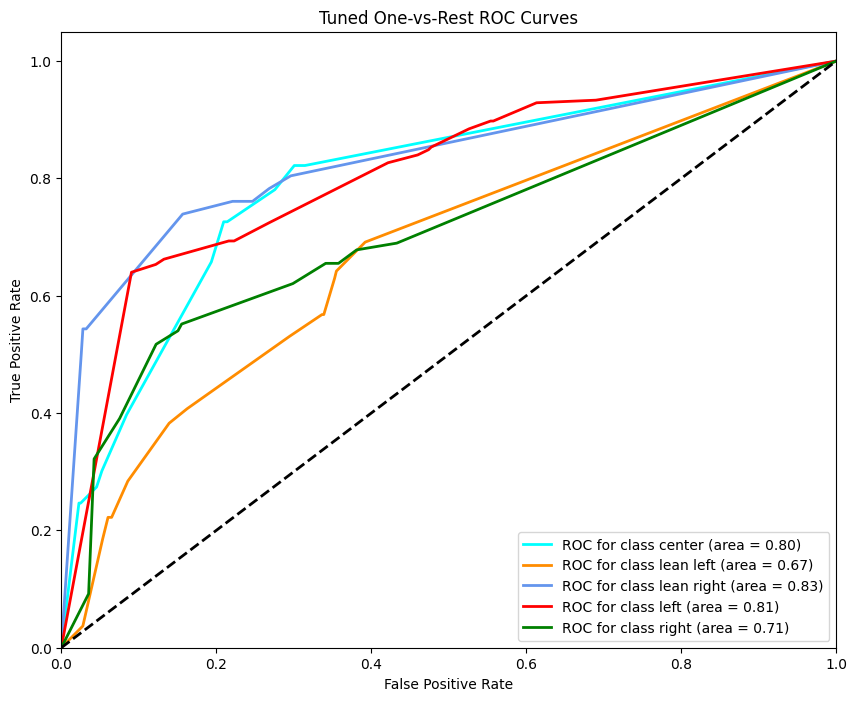

In [10]:
y_score = pipeline.predict_proba(X_test)

for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# Print AUC scores
print("ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

Despite lower accuracy, the tuned model demonstrated strong ROC-AUC values (≥ 0.74 for all classes), indicating good class separability. This suggests the model was well-calibrated in its predictions, even if threshold-based classification (precision/recall) varied.

## Final Conclusion

### Performance Metrics Summary 

| Model Version | Accuracy (%) | Weighted F1-score |
|---------------|--------------|-------------------|
| Unweighted    | 65.84        | 0.5658 (macro-avg)|
| Weighted      | 60.22        | 0.5209            |
| Tuned         | 56.52        | 0.5657            |

While accuracy decreases from unweighted to tuned, macro F1 improves in the tuned model — indicating better balance across classes, especially under class imbalance. This supports the use of macro F1 as the primary metric in this setting, where per-class fairness is critical.

### Summary of Decision Tree Variants

This study evaluated decision tree performance under class imbalance using three configurations:

- **Unweighted**: Highest accuracy (65.84%) but heavily biased toward the majority class, with poor minority class performance.
- **Weighted**: Improved recall for some minority classes, but overall macro F1 and accuracy declined.
- **Tuned**: Macro F1 (0.5657) is comparable to unweighted. However when observing ROC-AUC, tuned has a floor of 0.74 while unweighted has a floor of 0.65. This indicates better class seperability for the tuned model although accuracy was penalised (56.52%).


### Final Remarks

Overall, while accuracy declined with weighting and tuning, macro F1 and AUC metrics reveal that the tuned decision tree achieved the fairest class-wise performance — making it the most suitable for imbalanced classification tasks where equal treatment across classes is important.

While decision trees offer interpretability and simplicity, their performance — even with class weighting and tuning — remains limited in imbalanced multi-class text classification, with accuracy plateauing around 60%.

In conclusion, classification using decision tree performs rather poorly with ~60% accuracy even when hyperparameters have been tuned. We anticipate that LSTM and Transformers such as BERT will perform better on accuracy. 

Moving foward, all further models will be weighted and tuned by default given our learnings in decision tree. 
